In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Python

df1 = pd.read_csv('countries.csv')
df2 = pd.read_csv('events.csv')
df3 = pd.read_csv('products.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Python


#**Data overview**

**У датасеті міститься інформація щодо продажів продукції компанії, яка працює на світовому ринку і продає товари у звичайних магазинах та інтернет-магазинах. Датасет складається з трьох таблиць:**

###**Products**

    id - ідентифікатор товару

    item_type - назва товару

###**Countries**

    name - назва країни

    alpha-2 - дволітерні коди країн

    alpha-3 - трьохлітерні коди країн

    region - назва регіону

    sub-region - назва субрегіону

###**Events**

    Order ID - ідентифікатор замовлення

    Order Date - дата замовлення

    Ship Date - дата доставки

    Order Priority - пріоритет замовлення

    Country Code - код країни

    Product ID - ідентифікатор товару

    Sales Channel - канал продажу

    Units Sold - кількість проданого товару

    Unit Price - вартість товару

    Unit Cost - витрати на товар



####**Мета проєкту:**
Oчищення даних та проведення їх аналізу, знаходження цінних інсайтів діяльності компанії.

In [ ]:
# Об'єднаємо df2 (events) і df3 (products) по product IDs
df_merged_products = pd.merge(df2, df3, left_on='Product ID', right_on='id', how='left')

# Об'єднаємо результат першого об'єдання з df1 (countries) по country codes
df = pd.merge(df_merged_products, df1, left_on='Country Code', right_on='alpha-3', how='left')

# Огляд перших 5 рядків
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
#Загальна інформація
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
 10  id              1330 non-null   int64  
 11  item_type       1330 non-null   object 
 12  name            1248 non-null   object 
 13  alpha-2         1248 non-null   object 
 14  alpha-3         1248 non-null   object 
 15  region          1248 non-null   object 
 16  sub-region      1248 non-null   object 
dtypes: float64(3), int64(3), object(1

In [ ]:
# Базова статистика числових стовпців
df.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost,id
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812,5788.096241
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873,2820.728878
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000,1270.000000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000,3127.000000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000,5988.000000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000,8681.000000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000,8969.000000


#**Data cleaning**

In [ ]:

# Порахувати кількість пропусків у кожному стовпці
print("Кількість пропусків:")
print(df.isna().sum())

# Порахувати відсоток пропусків (дуже корисно для бізнес-звітів)
print("\nВідсоток пропусків (%):")
print((df.isna().sum() / len(df)) * 100)

Кількість пропусків:
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
id                 0
item_type          0
name              82
alpha-2           82
alpha-3           82
region            82
sub-region        82
dtype: int64

Відсоток пропусків (%):
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
id                0.000000
item_type         0.000000
name              6.165414
alpha-2           6.165414
alpha-3           6.165414
region            6.165414
sub-region        6.165414
dtype: float64


In [ ]:
#Кількістьь NaN/None невелика відносно усієї таблиці,тому видаляємо
df= df.dropna()

In [ ]:
#Заміна назв стовпців,щоб замість " " було "_". та перевод у нижній регістр
df.columns = df.columns.str.lower().str.replace(" ", "_")
#order_date та ship_date мають невірний формат 'object', потрібно змінити на 'datetime'
df['order_date']= pd.to_datetime(df['order_date'])
df['ship_date']= pd.to_datetime(df['ship_date'])

In [ ]:
# Пошук дублікатів

df.duplicated().sum()

np.int64(0)

In [ ]:
# Видалення непотрібних для аналізу стовпців
df = df.drop(columns=['id','alpha-2','alpha-3','sub-region', 'country_code'])


In [ ]:
# Заміна назви стовпця для зручності
df = df.rename(columns={'name': 'country'})

In [ ]:
# Перетворення данних у датасеті, щоб кожне слово починалося з великої літери
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").apply(lambda x: x.str.title())


In [ ]:
# Oгляд датасету
df.head()

,order_id,order_date,ship_date,order_priority,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country,region
0,100640618,2014-10-08,2014-10-18,M,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe
1,100983083,2016-08-11,2016-08-11,C,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe
3,102230632,2017-05-13,2017-06-13,L,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe
4,103435266,2012-08-11,2012-09-18,H,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe
5,103450715,2015-03-15,2015-04-18,H,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe


In [ ]:
# Збереження у csv формат
df.to_csv('df_analis.csv', index=False)

#**Data analysis and visualization**

In [ ]:
#Перевірка ключових метрик діяльності компанії
count_order = df['order_id'].count()
revenue = df['unit_price']* df['units_sold']
sum_revenue = revenue.sum()
sum_quaninty = df['units_sold'].sum()
count_country = len(df['country'].unique())
date_min = df['order_date'].min().date()
date_max = df['order_date'].max().date()

print(f'Замовлення були зроблені у період між {date_min} та {date_max}')
print(f'Загальна кількість замовлень: {count_order}')
print(f'Загальний revenue: {sum_revenue}$')
print(f'Загальна кількість проданного товару: {sum_quaninty}')
print(f'Загальна кількість країн: {count_country}')


Замовлення були зроблені у період між 2010-01-01 та 2017-07-22
Загальна кількість замовлень: 1246
Загальний revenue: 1598983761.26$
Загальна кількість проданного товару: 6171671.0
Загальна кількість країн: 45


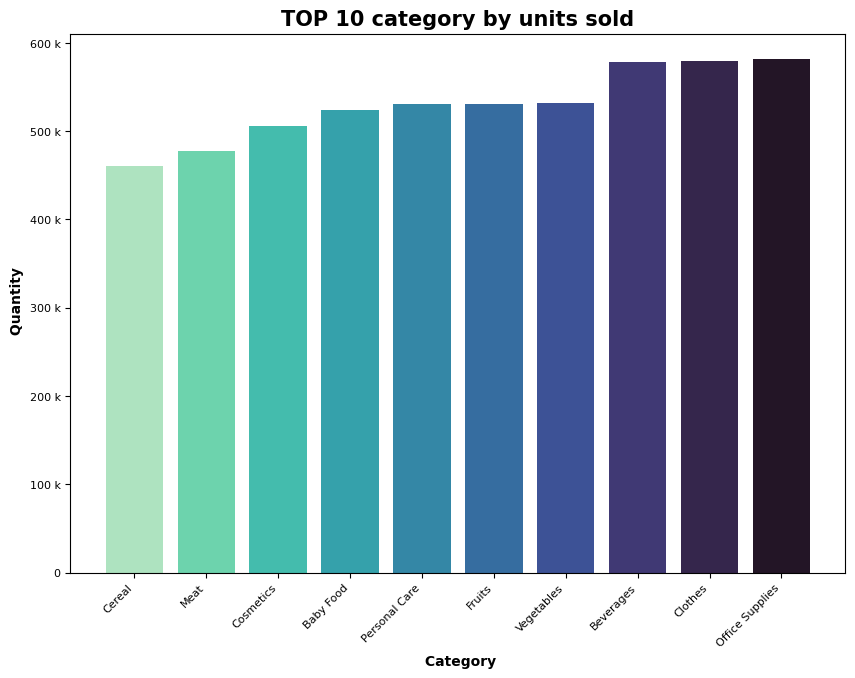

In [ ]:
#Налаштування розміру
plt.figure(figsize=(10, 7))
#Попередне групування по категоріям товарів за кількістю проданного товару
gr_quanity_category = df.groupby('item_type')['units_sold'].sum().sort_values(ascending=True).tail(10)
#Cтворення стовпчастої діаграми
plt.bar(
    gr_quanity_category.index
    , gr_quanity_category.values
    , color=sns.color_palette(
        "mako_r"
        , len(gr_quanity_category.index)) # налаштування кольору

)
plt.title(
    'TOP 10 category by units sold'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Category'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Quantity'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**Топ 3 популярні категорії:**
1. Office Supplies
2. Clothes
3. Beverages


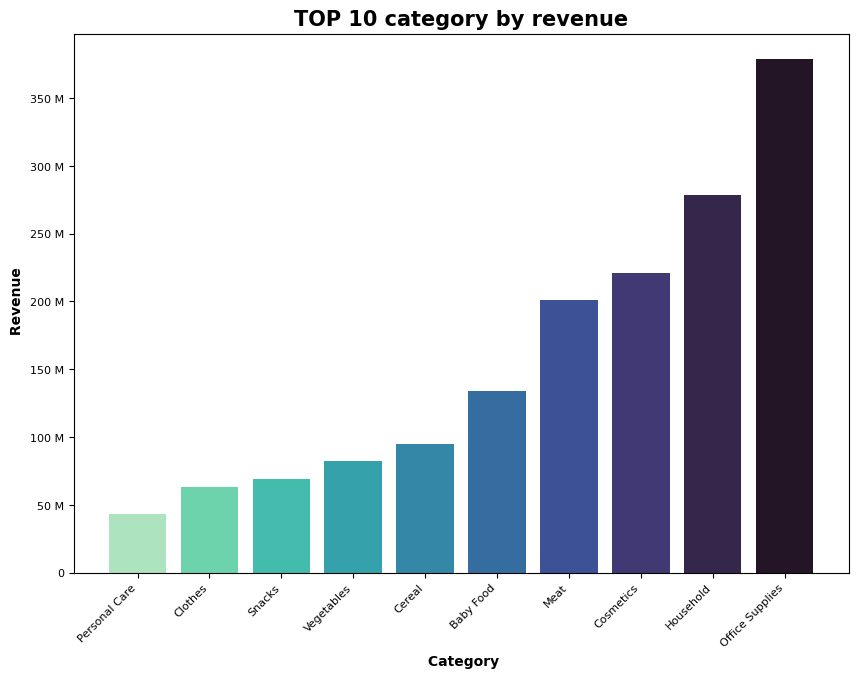

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Розрахунок виторгу
df['revenue'] = df['unit_price']*df['units_sold']
# Попереднє группування
gr_revenue_category = df.groupby('item_type')['revenue'].sum().sort_values(ascending=True).tail(10)
# Створення стовпачатої діаграми
plt.bar(
    gr_revenue_category.index
    , gr_revenue_category.values
    , color=sns.color_palette("mako_r", len(gr_quanity_category.index)) #налаштування кольору

)
plt.title(
    'TOP 10 category by revenue'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Category'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Revenue'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 категорії за виторгом:**
1. Office Supplies
2. Household
3. Cosmetics

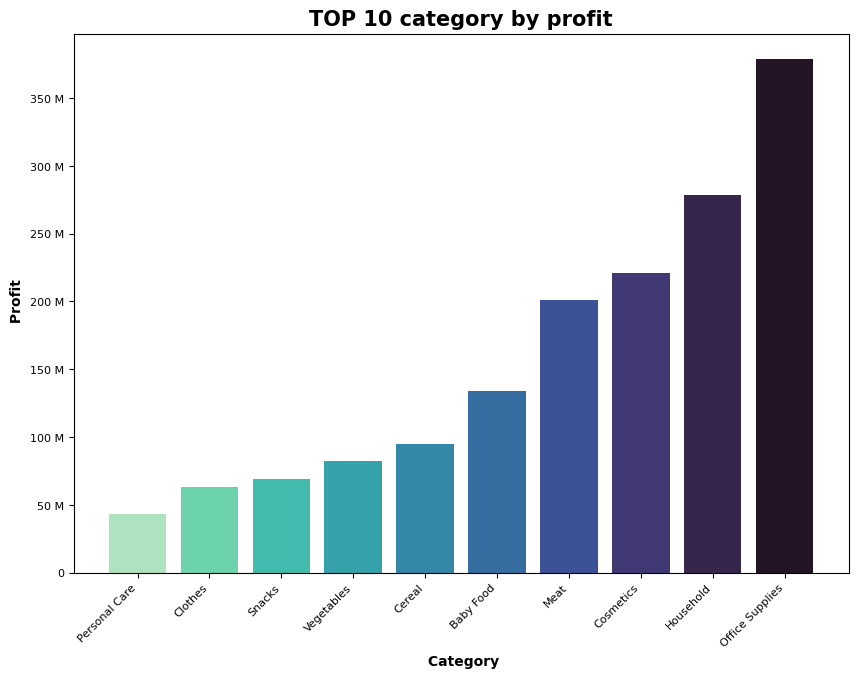

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Розрахунок та створення нового стовпця з прибутком
df['profit'] = df['revenue'] - df['unit_cost']
# Попереднє групування
gr_prodit_category = df.groupby('item_type')['profit'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_prodit_category.index
    , gr_prodit_category.values
    , color=sns.color_palette("mako_r", len(gr_quanity_category.index))

)
plt.title(
    'TOP 10 category by profit'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Category'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Profit'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 категорії за прибутком**
1. Office Supplies
2. Household
3. Cosmetics


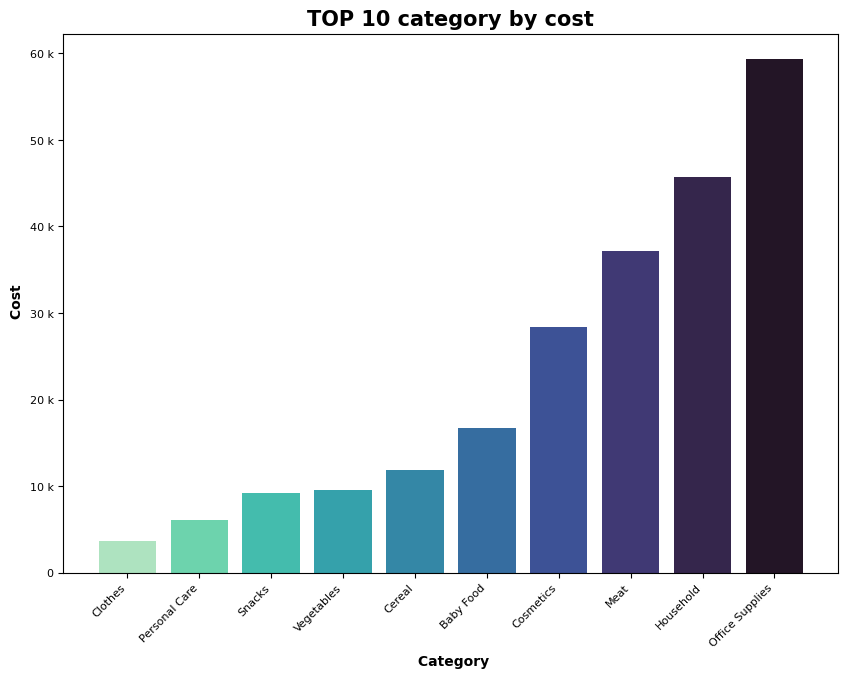

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попередне групування
gr_cost_category = df.groupby('item_type')['unit_cost'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_cost_category.index
    ,gr_cost_category.values
    , color=sns.color_palette("mako_r", len(gr_quanity_category.index))

)
plt.title(
    'TOP 10 category by cost'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Category'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Cost'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

In [ ]:
# 1. ГРУПУВАННЯ: Рахуємо загальний прибуток (profit) для кожної категорії
pareto = df.groupby('item_type')['profit'].sum().reset_index()

# 2. СОРТУВАННЯ: Обов'язково від найбільшого прибутку до найменшого
pareto= pareto.sort_values(by='profit', ascending=False).reset_index(drop=True)

# 3. НАКОПИЧУВАЛЬНА СУМА: Рахуємо суму прибутку наростаючим підсумком
pareto['cumulative_profit'] = pareto['profit'].cumsum()

# 4. ВІДСОТОК: Рахуємо відсоток накопичувального прибутку від загальної суми
total_profit = pareto['profit'].sum()
pareto['cumulative_percentage'] = (pareto['cumulative_profit'] / total_profit) * 100

# Дивимось на результат
print(pareto)

          item_type        profit  cumulative_profit  cumulative_percentage
0   Office Supplies  3.786069e+08       3.786069e+08              23.681410
1         Household  2.788287e+08       6.574356e+08              41.121810
2         Cosmetics  2.212770e+08       8.787126e+08              54.962419
3              Meat  2.013026e+08       1.080015e+09              67.553658
4         Baby Food  1.338176e+08       1.213833e+09              75.923790
5            Cereal  9.466489e+07       1.308498e+09              81.844966
6        Vegetables  8.202894e+07       1.390527e+09              86.975778
7            Snacks  6.920424e+07       1.459731e+09              91.304420
8           Clothes  6.330367e+07       1.523035e+09              95.263989
9     Personal Care  4.334020e+07       1.566375e+09              97.974866
10        Beverages  2.742208e+07       1.593797e+09              99.690085
11           Fruits  4.954777e+06       1.598752e+09             100.000000


/tmp/ipykernel_533/3304731688.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_533/3304731688.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(
/tmp/ipykernel_533/3304731688.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_533/3304731688.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(


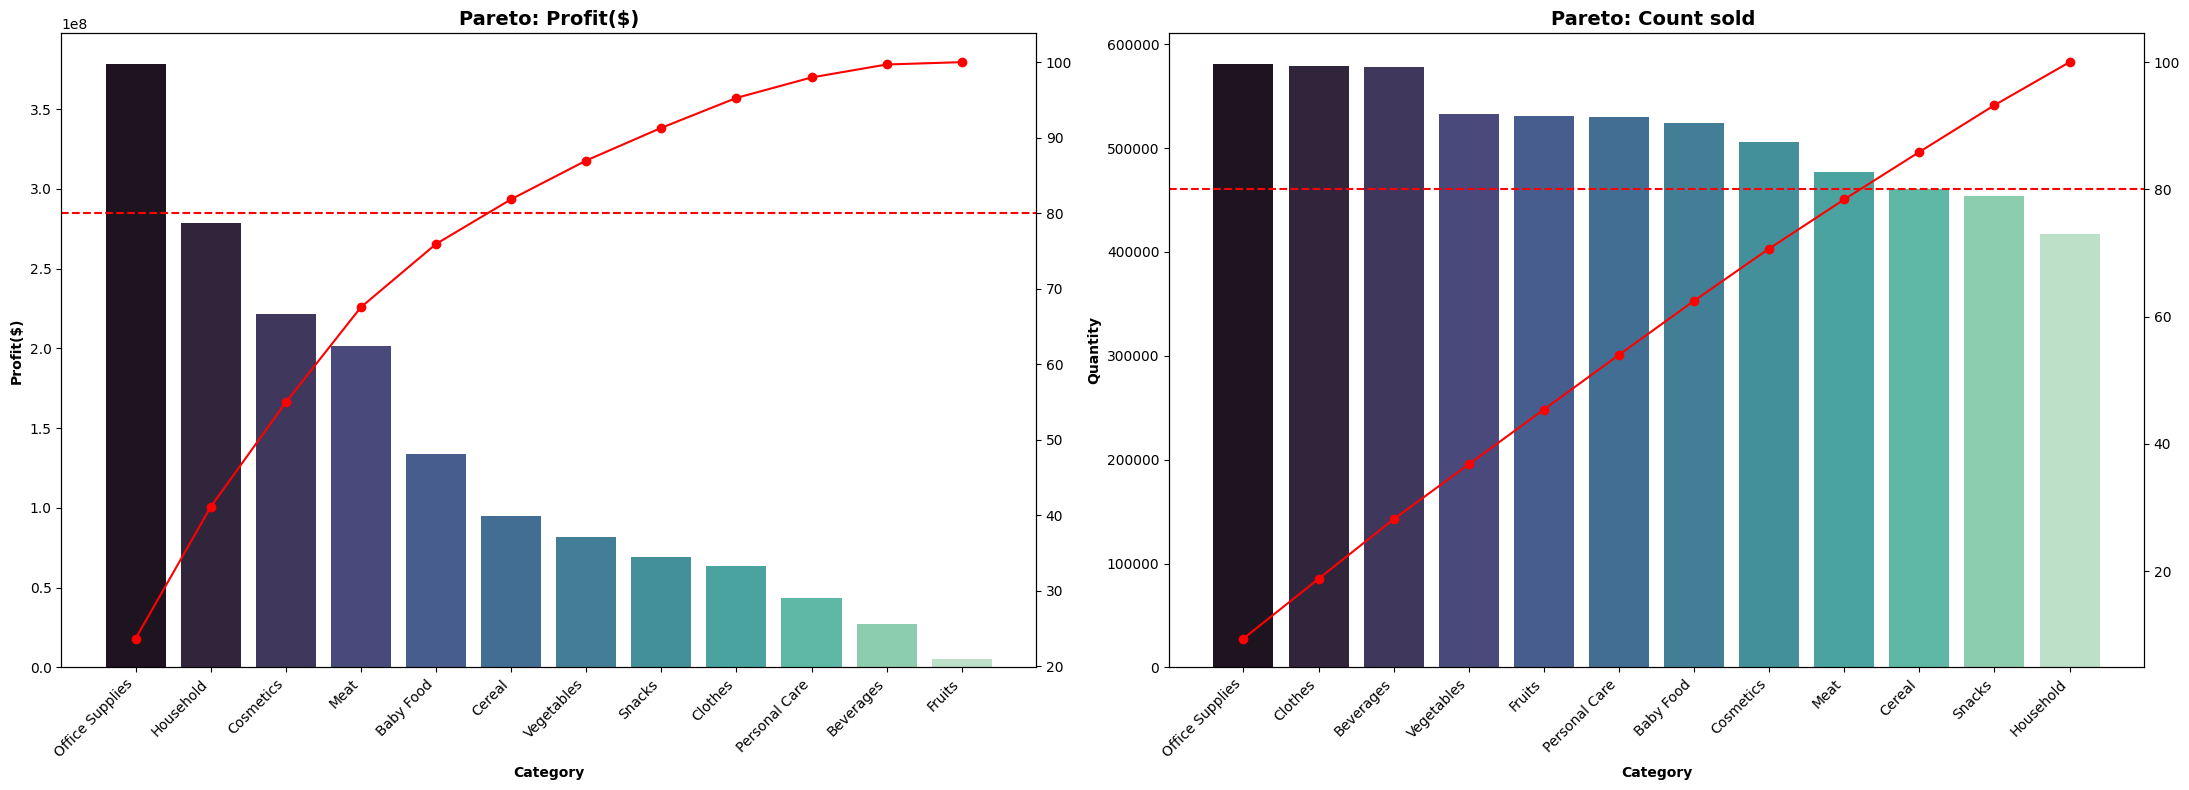

In [ ]:

# Готуємо дані для другого графіка (за кількістю продажів)
qty_df = df.groupby('item_type')['units_sold'].sum().reset_index()
qty_df = qty_df.sort_values(by='units_sold', ascending=False).reset_index(drop=True)
qty_df['Cum_Qty'] = qty_df['units_sold'].cumsum()
qty_df['cumulative_percentage'] = (qty_df['Cum_Qty'] / qty_df['units_sold'].sum()) * 100

# Створюємо сітку 1 рядок, 2 стовпчики
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(22, 8))

# ЛІВИЙ ГРАФІК: ПРИБУТОК
sns.barplot(
    x='item_type'
    , y='profit'
    , data=pareto
    , ax=ax1
    , palette='mako'
    )
ax1.set_title(
    'Pareto: Profit($)'
    , fontsize=14
    , fontweight='bold'
    )
ax1.set_xlabel(
    'Category'
    , fontsize=10
    , fontweight='bold'
    )
ax1.set_ylabel(
    'Profit($)'
    , fontsize=10
    , fontweight='bold'
    )
ax1.set_xticklabels(
    ax1.get_xticklabels()
    , rotation=45
    , ha='right'
    )
ax2 = ax1.twinx()
ax2.plot(
    pareto['item_type']
    , pareto['cumulative_percentage']
    , color='red'
    , marker='o'
    )
ax2.axhline(
            80
            , color='red'
            , linestyle='--')

# ПРАВИЙ ГРАФІК: КІЛЬКІСТЬ ПРОДАЖІВ
sns.barplot(
    x='item_type'
    , y='units_sold'
    , data=qty_df
    , ax=ax3
    , palette='mako'
    )
ax3.set_title(
    'Pareto: Count sold '
    , fontsize=14
    , fontweight='bold'
    )
ax3.set_xlabel(
    'Category'
    , fontsize=10
    , fontweight='bold'
    )
ax3.set_ylabel(
    'Quantity'
    , fontsize=10
    , fontweight='bold'
    )
ax3.set_xticklabels(
    ax3.get_xticklabels()
    , rotation=45
    , ha='right'
    )
ax4 = ax3.twinx()
ax4.plot(
    qty_df['item_type']
    , qty_df['cumulative_percentage']
    , color='red'
    , marker='o'
    )
ax4.axhline(
    80
    , color='red'
    , linestyle='--'
    )

plt.tight_layout()
plt.show()

**За прибутком:**

**Група А:** 'Office Suplies','Household', 'Cosmetics', 'Meat' , 'Baby Food'

**Група В:** 'Cereal', 'Vegetables', 'Snacks', 'Clothes'

**Група С:** 'Personal Care' , 'Beverages' , 'Fruits'

**За кількістю продажів:**

**Кількість проданих одиниць товару розподілена абсолютно рівномірно між усіма категоріями (маємо високий рівень продажів по кожній позиції, близько 400 000 – 600 000 штук кожна).**

**Група А:** 'Office Suplies', 'Clothes', , 'Beverages' , Vegetables', 'Fruits', 'Personal Care' , 'Baby Food',  'Cosmetics', 'Meat'  

**Група В:** 'Cereal', 'Snacks'

**Група С:**  'Household'



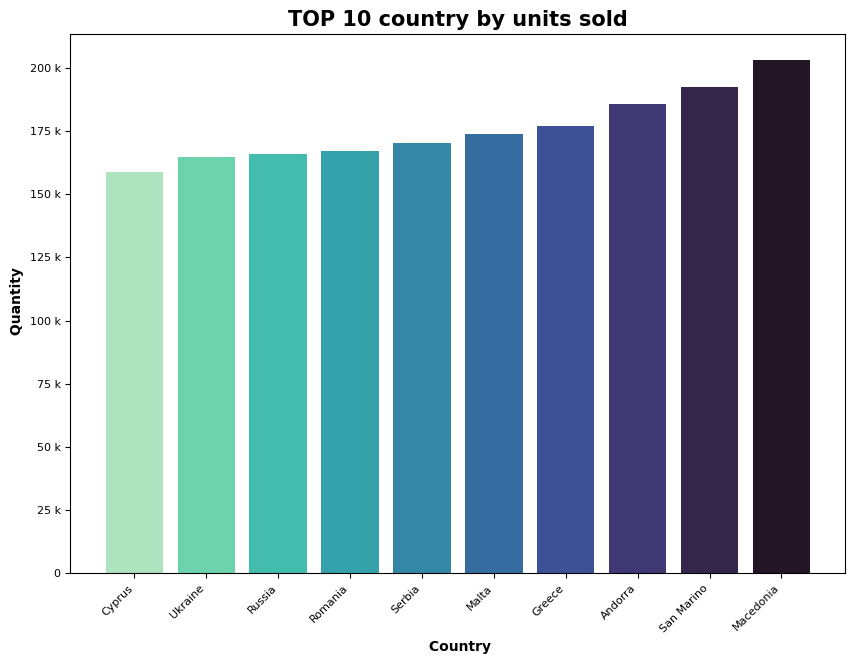

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попередне групування
gr_quanity_country = df.groupby('country')['units_sold'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_quanity_country.index
    , gr_quanity_country.values
    , color=sns.color_palette("mako_r", len(gr_quanity_country.index))

)
plt.title(
    'TOP 10 country by units sold'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Quantity'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 країни за кількістю проданого товару:**
1. Macedonia
2. San Marino
3. Andora

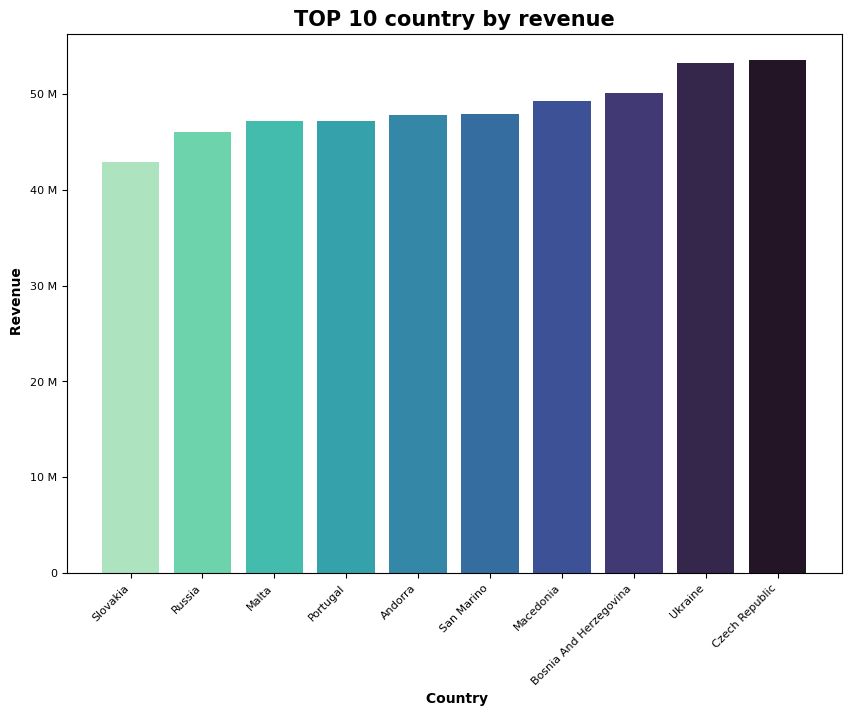

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попереднє групування
gr_revenue_country = df.groupby('country')['revenue'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_revenue_country.index
    , gr_revenue_country.values
    , color=sns.color_palette("mako_r", len(gr_revenue_country.index))

)
plt.title(
    'TOP 10 country by revenue'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Revenue'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 країни за виторгом:**
1. Сzech Republic
2. Ukraine
3. Bosnia And Herzegovina

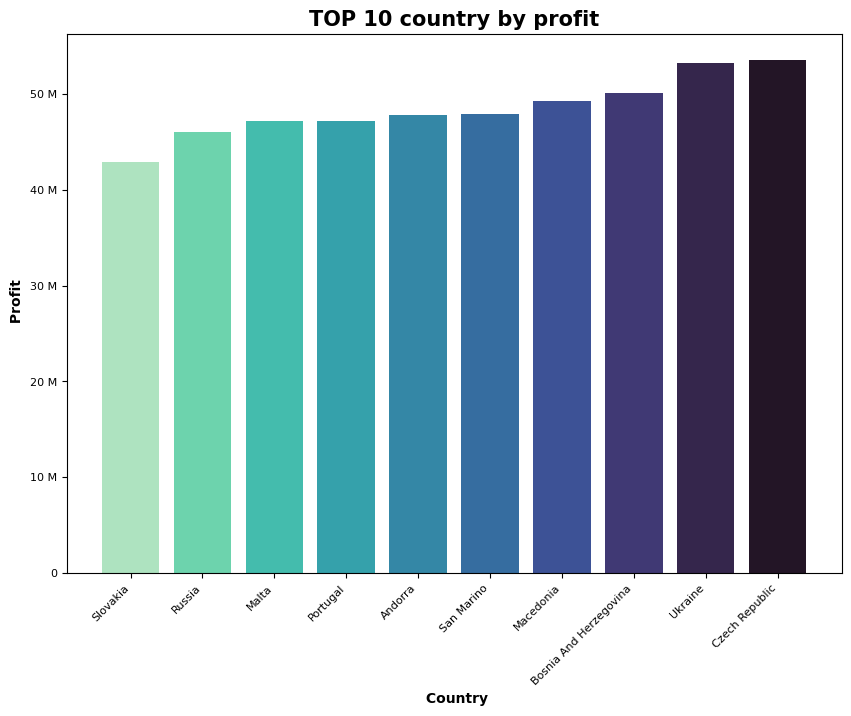

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попереднє групування
gr_profit_country = df.groupby('country')['profit'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_profit_country.index
    , gr_profit_country.values
    , color=sns.color_palette("mako_r", len(gr_profit_country.index))

)
plt.title(
    'TOP 10 country by profit'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Profit'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 країни за прибутком:**
1. Czech Republic
2. Ukraine
3. Bosnia And Herzegovina

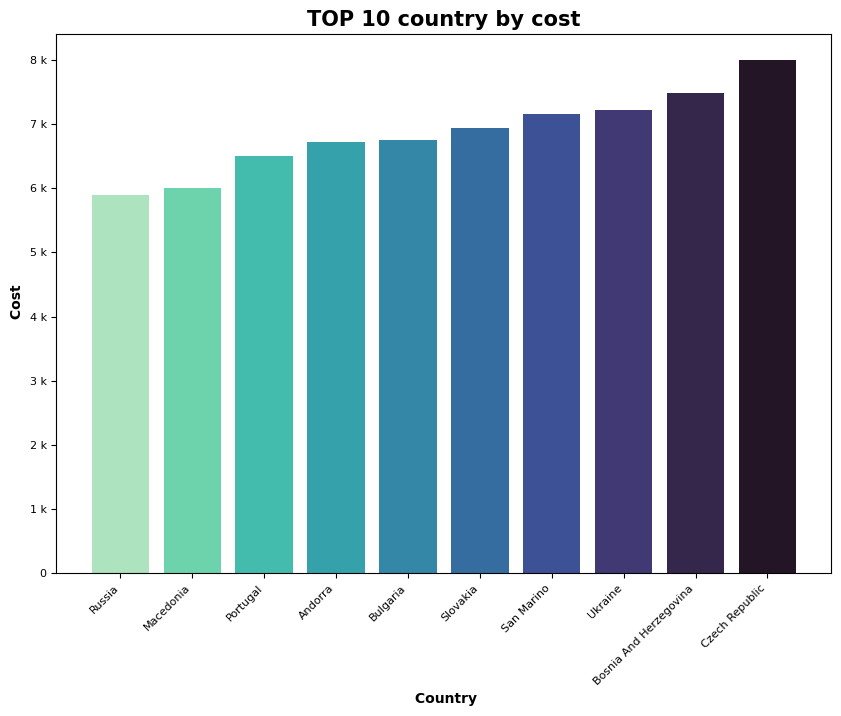

In [ ]:
#  Розмір
plt.figure(figsize=(10, 7))
# Попереднє групування
gr_cost_country = df.groupby('country')['unit_cost'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
plt.bar(
    gr_cost_country.index
    , gr_cost_country.values
    , color=sns.color_palette("mako_r", len(gr_cost_country.index))

)
plt.title(
    'TOP 10 country by cost'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Cost'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , rotation=45
    , ha='right'
)
plt.yticks(
    fontsize=8
)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.show()

###**ТОП 3 країни з найбільшими витратами на товар:**
1. Czech Republic
2. Bosnia And Herzegovina
3. Ukraine

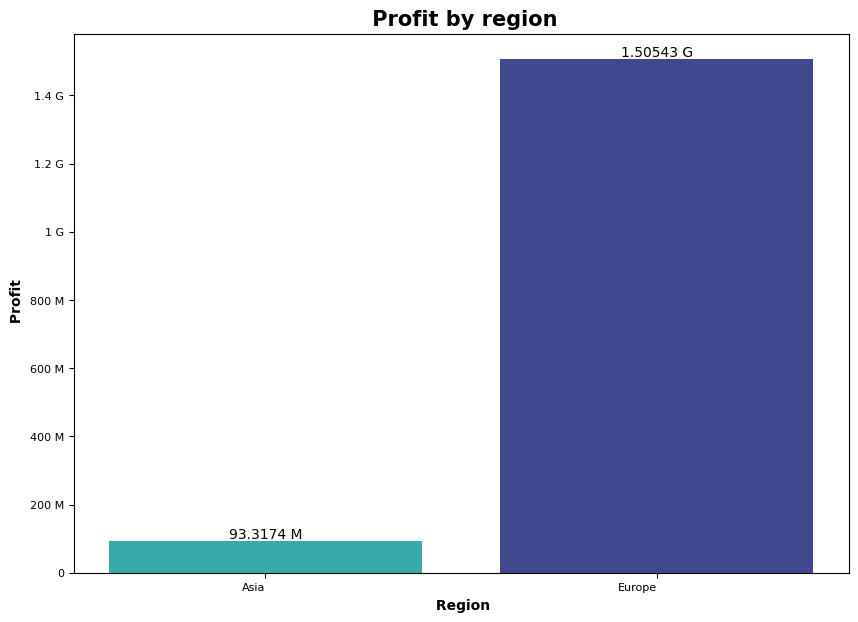

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попереднє групування
gr_profit_region = df.groupby('region')['profit'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
bars=plt.bar(
    gr_profit_region.index
    , gr_profit_region.values
    , color=sns.color_palette("mako_r", len(gr_profit_region.index))

)
plt.title(
    ' Profit by region'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Region'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Profit'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , ha='right'
)
plt.yticks(
    fontsize=8
)

formatter = ticker.EngFormatter()
plt.gca().yaxis.set_major_formatter(formatter)
# Підписи над стовпцями
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2
        , bar.get_height()
        , formatter(bar.get_height())
        , ha = 'center'
        , va = 'bottom'


    )

plt.show()

**На стовпчастій діаграмі видно, що прибуток у 'Europe' значно більший ніж у 'Asia'(~у 16 разів)**

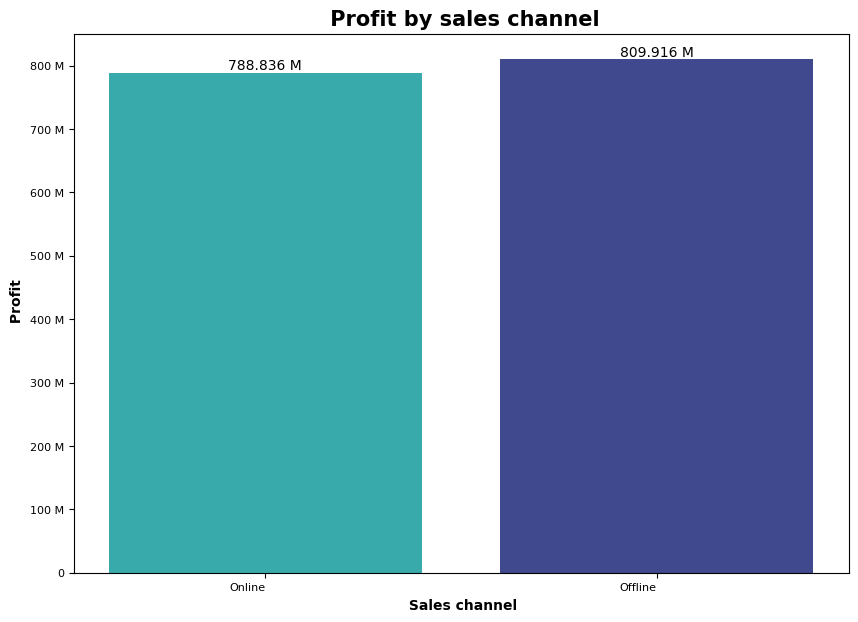

In [ ]:
# Розмір
plt.figure(figsize=(10, 7))
# Попережнє групування
gr_profit_sales_channel = df.groupby('sales_channel')['profit'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
bars=plt.bar(
    gr_profit_sales_channel.index
    ,gr_profit_sales_channel.values
    , color=sns.color_palette("mako_r", len(gr_profit_sales_channel.index))

)
plt.title(
    ' Profit by sales channel'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Sales channel'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Profit'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=8
    , ha='right'
)
plt.yticks(
    fontsize=8
)

formatter = ticker.EngFormatter()
plt.gca().yaxis.set_major_formatter(formatter)

# Підписи над стовпцями
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2
        , bar.get_height()
        , formatter(bar.get_height())
        , ha = 'center'
        , va = 'bottom'


    )

plt.show()

**На стовпчастій діаграмі видно,що прибуток від Online-каналу незначно поступається Offline-сегменту, проте ця різниця є мінімальною. Обидва канали працюють однаково ефективно та забезпечують збалансоване надходження доходу.**

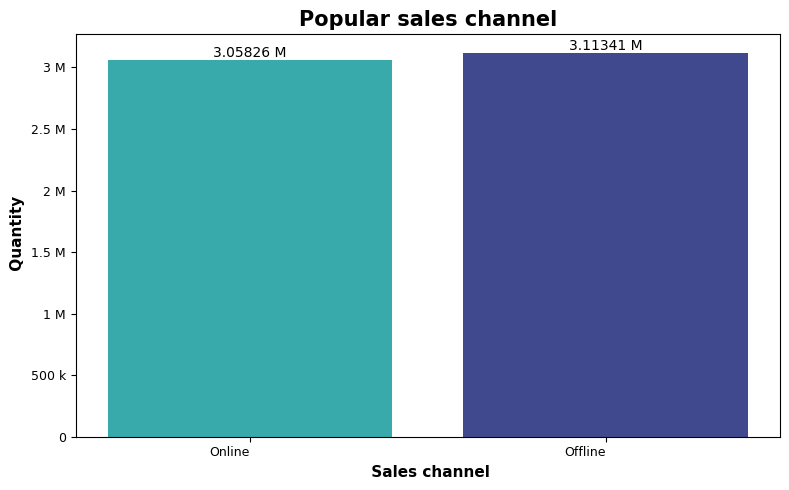

In [ ]:
#  Розмір
plt.figure(figsize=(8, 5))
# Попереднє групування
gr_quanity_channel = df.groupby('sales_channel')['units_sold'].sum().sort_values(ascending=True).tail(10)
# Створення стовпчастої діаграми
bars = plt.bar(
    gr_quanity_channel.index
    ,gr_quanity_channel.values
    , color=sns.color_palette("mako_r", len(gr_quanity_channel.index))
)
plt.title(
    'Popular sales channel'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Sales channel'
    , fontsize=11
    , fontweight='bold'
)
plt.ylabel(
    ' Quantity'
    , fontsize=11
    , fontweight='bold'
)
plt.xticks(
    fontsize=9
    , ha='right'
)
plt.yticks(
    fontsize=9
)

formatter = ticker.EngFormatter()
plt.gca().yaxis.set_major_formatter(formatter)
# Підписи над стовпцями
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2
        , bar.get_height()
        , formatter(bar.get_height())
        , ha = 'center'
        , va = 'bottom'
    )

plt.tight_layout()
plt.show()

**На стовпчастій діаграмі видно,що кількість продажів від Online-каналу незначно поступається Offline-сегменту, проте ця різниця є мінімальною.**

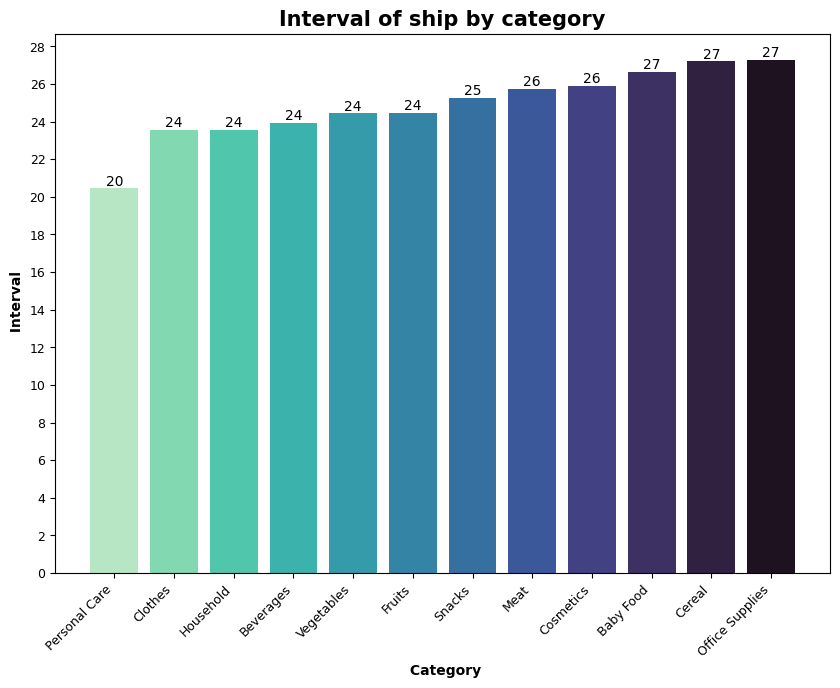

In [ ]:
# Розрахунок кількості днів,що пішла до доставку
df['interval'] = (df['ship_date']- df['order_date']).dt.days
# Попереднє групування за категорією
gr_int_category= df.groupby('item_type')['interval'].mean().sort_values(ascending=True)
# Розмір
plt.figure(figsize=(10,7))
# Створення стовпчикової діаграми
bars = plt.bar(
    gr_int_category.index
    , gr_int_category.values
    , color=sns.color_palette("mako_r", len(gr_int_category.index))
)
plt.title(
    'Interval of ship by category'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Category'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Interval'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=9
    , rotation=45
    , ha='right'
)
plt.yticks(
    np.arange(0, 30, 2)
    ,fontsize=9

)
# Підписи над стовпцями
for bar in bars:
      plt.text(
          bar.get_x() + bar.get_width() / 2
          , bar.get_height() +0
          , f'{bar.get_height():,.0f}'
          , ha= 'center'
          , va= 'bottom'
  )

plt.show()

Аналіз логістичних показників виявив,що середній термін доставки коливається в діапазоні від 20 до 27 днів
- Мінімальний середній термін доставки(20днів): 'personal care'
- Максимальний середній термін доставки(27днів): 'Officе Supplies', 'Cereal' , 'Baby Food'

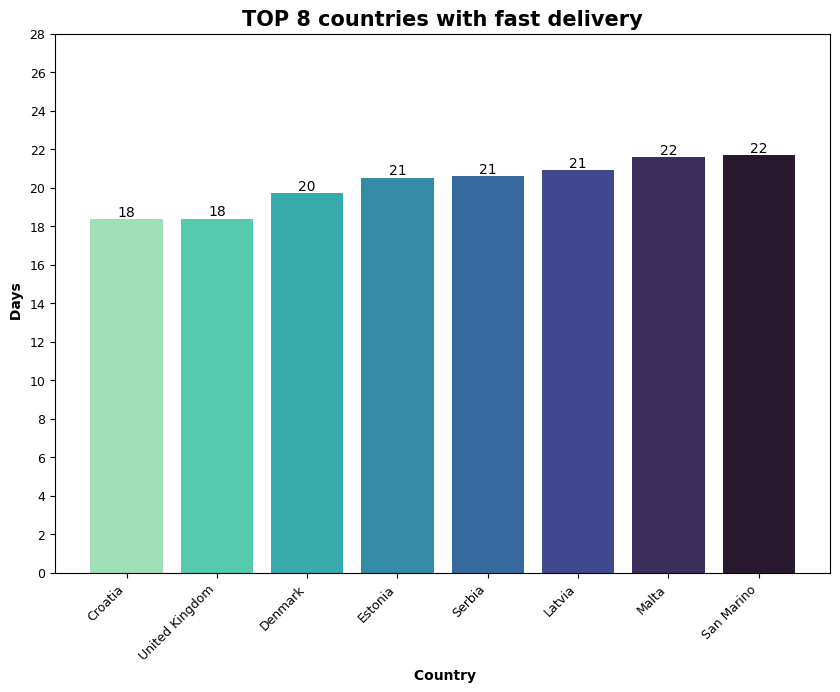

In [ ]:
# Попереднє групування за країнами
gr_int_country= df.groupby('country')['interval'].mean().sort_values(ascending=True).head(8)
# Розмір
plt.figure(figsize=(10,7))
# Створення стовпчикової діаграми
bars = plt.bar(
    gr_int_country.index
    , gr_int_country.values
    , color=sns.color_palette("mako_r", len(gr_int_country.index))
)
plt.title(
    'TOP 8 countries with fast delivery'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Days'
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=9
    , rotation=45
    , ha='right'
)
plt.yticks(
    np.arange(0, 30, 2)
    ,fontsize=9

)
# Підписи над стовпцями
for bar in bars:
      plt.text(
          bar.get_x() + bar.get_width() / 2
          , bar.get_height() +0
          , f'{bar.get_height():,.0f}'
          , ha= 'center'
          , va= 'bottom'
  )

plt.show()

Найшвидша доставка відбувається у країнах:
1. Сroatia (18 днів)
2. United Kingdom (18 днів)
3. Denmark (20 днів)

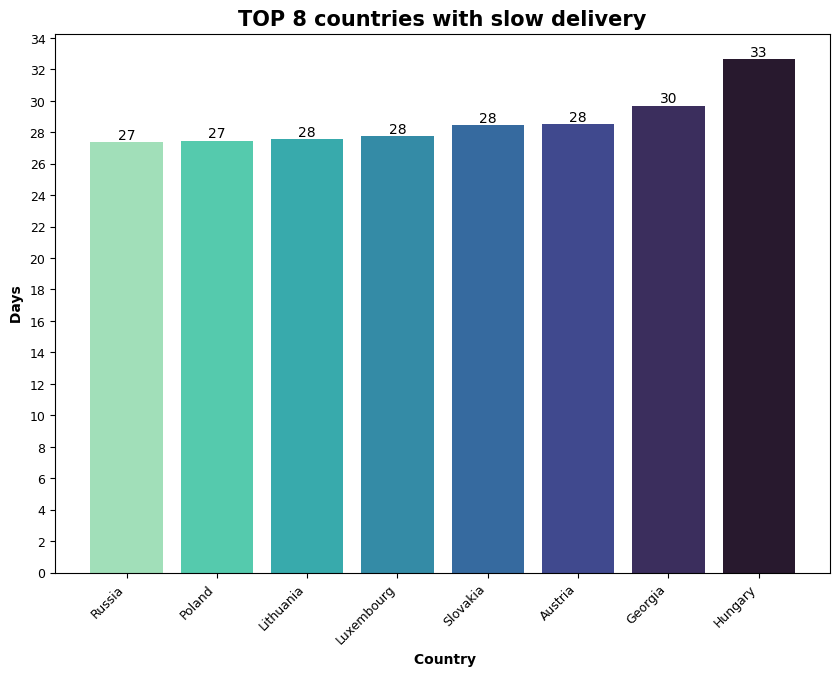

In [ ]:
# Попереднє групування
gr_int_country= df.groupby('country')['interval'].mean().sort_values(ascending=True).tail(8)
# Розмір
plt.figure(figsize=(10,7))
# Створення стовпчикової діаграми
bars = plt.bar(
    gr_int_country.index
    , gr_int_country.values
    , color=sns.color_palette("mako_r", len(gr_int_country.index))
)
plt.title(
    'TOP 8 countries with slow delivery'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Country'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Days '
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=9
    , rotation=45
    , ha='right'
)
plt.yticks(
    np.arange(0, 35, 2)
    ,fontsize=9

)
# Підписи над стовпчиками
for bar in bars:
      plt.text(
          bar.get_x() + bar.get_width() / 2
          , bar.get_height() +0
          , f'{bar.get_height():,.0f}'
          , ha= 'center'
          , va= 'bottom'
  )

plt.show()

Найповільніша доставка відбувається у країнах:
1. Hungary (33дні)
2. Georgia (30днів)
3. Austia and Slovakia (28днів)

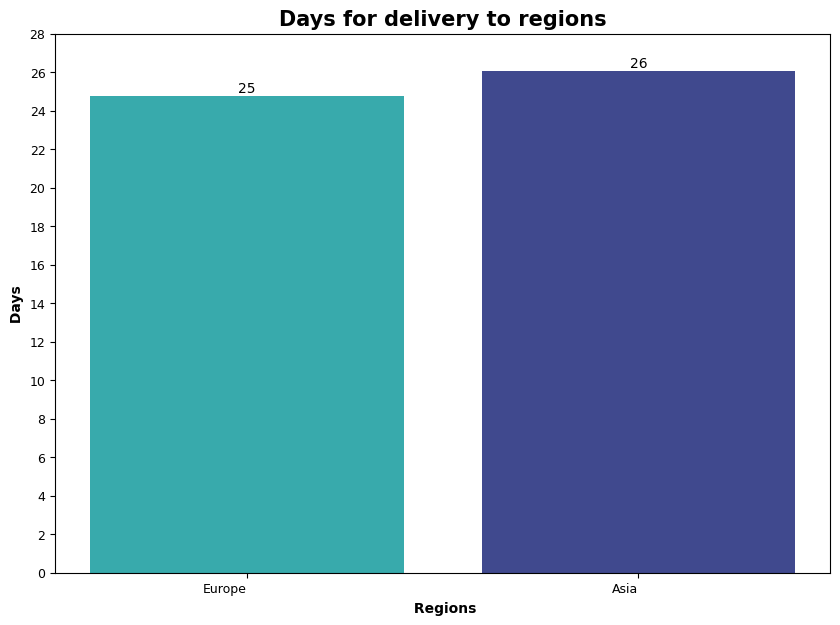

In [ ]:
# Попереднє групування за регіоном
gr_int_region= df.groupby('region')['interval'].mean().sort_values(ascending=True)
# Розмір
plt.figure(figsize=(10,7))
# Створення стовпчикової діаграми
bars = plt.bar(
    gr_int_region.index
    , gr_int_region.values
    , color=sns.color_palette("mako_r", len(gr_int_region.index))
)
plt.title(
    'Days for delivery to regions'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    ' Regions'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    ' Days '
    , fontsize=10
    , fontweight='bold'
)
plt.xticks(
    fontsize=9
    , ha='right'
)
plt.yticks(
    np.arange(0, 30, 2)
    ,fontsize=9

)
 # Створення підаисів над стовпцями
for bar in bars:
      plt.text(
          bar.get_x() + bar.get_width() / 2
          , bar.get_height() +0
          , f'{bar.get_height():,.0f}'
          , ha= 'center'
          , va= 'bottom'
  )

plt.show()

По Європі доставка в сереньому відбувається за  25днів, у Азії в середньому за 26 днів

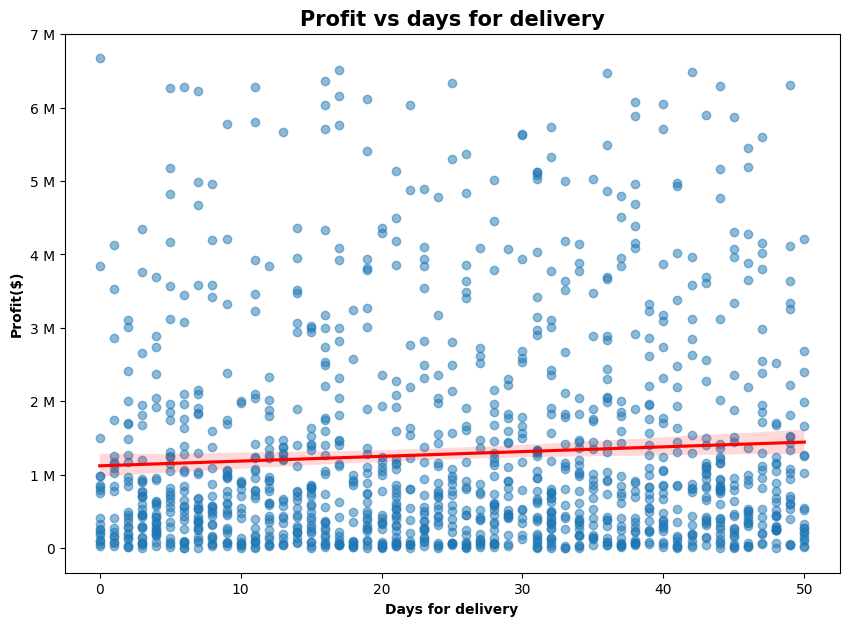

In [ ]:
# Розмір
plt.figure(figsize=(10,7))
# Створення Scatter Plot
sns.regplot(
    data=df
    , x='interval'
    , y='profit'
    , scatter_kws={'alpha':0.5}
    , line_kws={'color':'red'}
)
plt.title(
    'Profit vs days for delivery'
    , fontsize=15
    , fontweight='bold'
)
plt.xlabel(
    'Days for delivery'
    , fontsize=10
    , fontweight='bold'
)
plt.ylabel(
    'Profit($)'
    , fontsize=10
    , fontweight='bold'
)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter() )
plt.show()

In [ ]:
correlation = df['interval'].corr(df['profit'])
print(f"Коефіцієнт кореляції: {correlation}")

Коефіцієнт кореляції: 0.06490849679449842


Графік розсіювання фіксує нульову кореляцію між днями на доставку та прибутком,це підтверджує хаотичний розподіл точок на графіку розсіювання і коефіцієнт кореляції.

Незалежно від тривалості доставки,діапазон коливання прибутку залишається ідентичним.

Основний масив замовлень зосереджений у нижньому сегменті доходу(до 1.5млн).

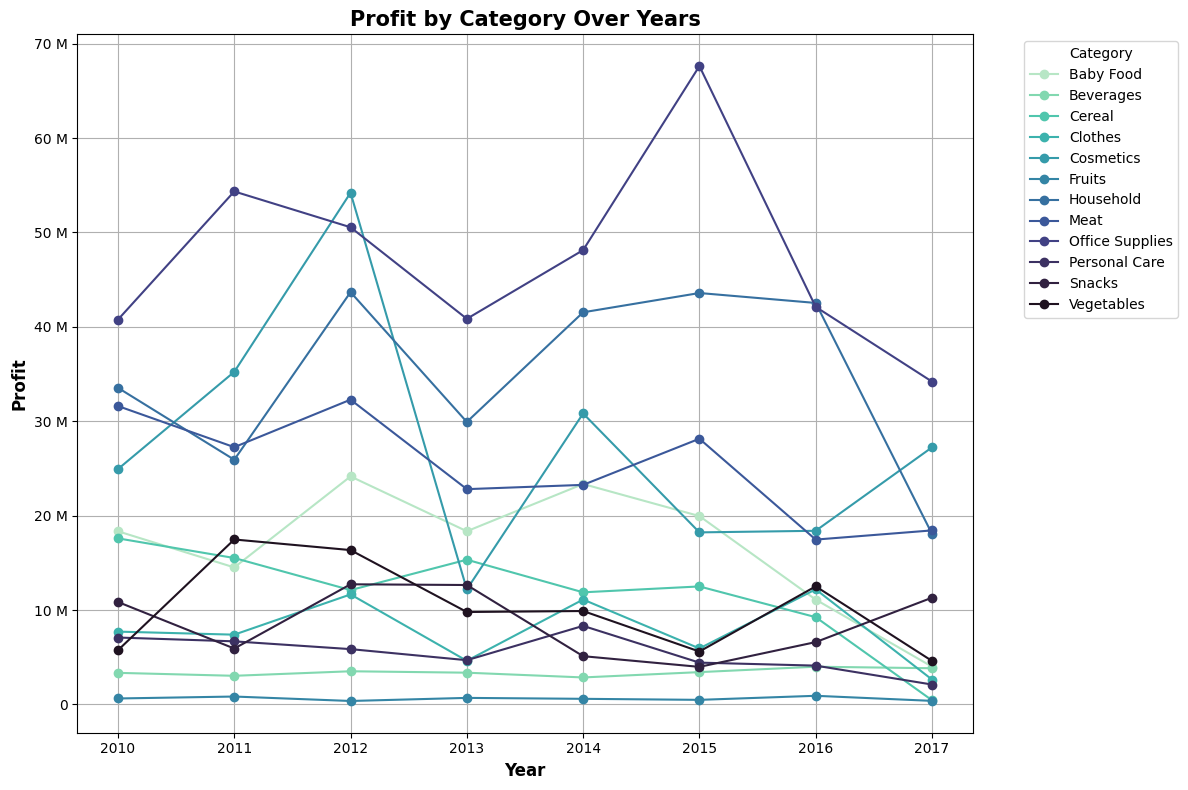

In [ ]:
# рік з дати
df['year'] = df['order_date'].dt.year
# Попереднє групування
gr_categoty_profit_year = df.groupby(['item_type', 'year'])['profit'].sum().unstack(level=0)
plt.figure(figsize=(12,8))
# Створення лінійного графіка
gr_categoty_profit_year.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette(
        'mako_r'
        , n_colors=len(gr_categoty_profit_year.columns)
        )
)
plt.title(
    'Profit by Category Over Years'
    , fontsize=15
    , fontweight='bold')

plt.xlabel(
    'Year'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Profit'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Category'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left') #створення легенди
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

**Динаміка річного прибутку по категоріях:**
Динаміка по всіх категоріях досить волатильна.

Категорія 'Office Supplies' стабільно утримує позицію лідера по прибутку.

Динаміка категорій 'Beverages' 'Fruits' 'Personal care' лінійно-горизонтальна на протязі всих 7 років.

 За останній рік позитивна динаміка спостерігається  у категорій 'Vegetables', та 'Cosmetics', інші мають негативну динаміку.

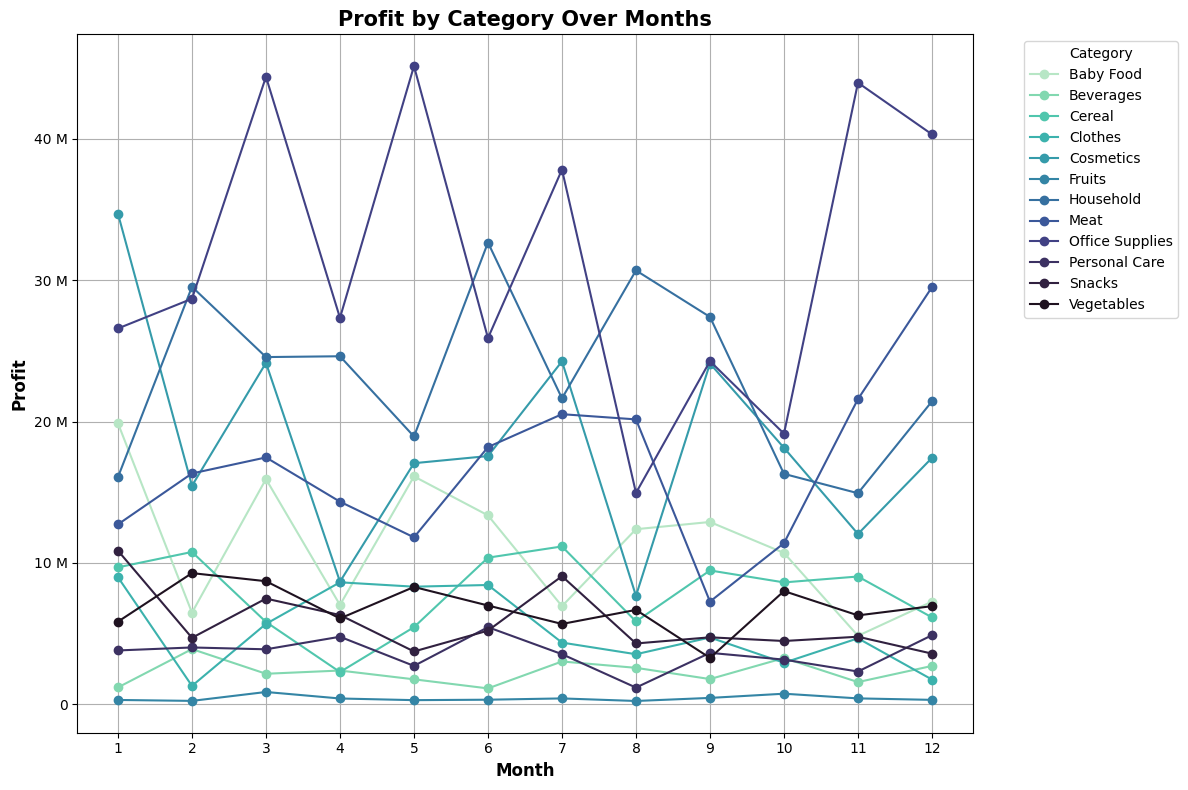

In [ ]:
# Ствоврення стовпчика з місяецем
df['month'] = df['order_date'].dt.month
# Групування по місяцям
gr_categoty_profit_time = df.groupby(['item_type', 'month'])['profit'].sum().unstack(level=0)
# Розмір
plt.figure(figsize=(12,8))
# Створення лінійного графіку
gr_categoty_profit_time.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette(
        'mako_r'
        , n_colors=len(gr_categoty_profit_time.columns))
)

plt.title(
    'Profit by Category Over Months'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Month'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Profit'
    , fontsize=12
    , fontweight='bold'
    )
plt.xticks(range(1,13,1))
plt.legend(
    title='Category'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left') # легенда
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

**Динаміка помісячного прибутку по категоріям** досить волатильна
Не видно чітких закономірностей.

Категорія 'Office Supplies' стабільно утримує позицію лідера по прибутку.
Динаміка категорій 'Beverages' 'Fruits' 'Personal care' лінійно-горизонтальна на протязі всих 7 років.

За останній рік позитивна динаміка спостерігається у категорій 'Vegetables', та 'Cosmetics', інші мають негативну динаміку.


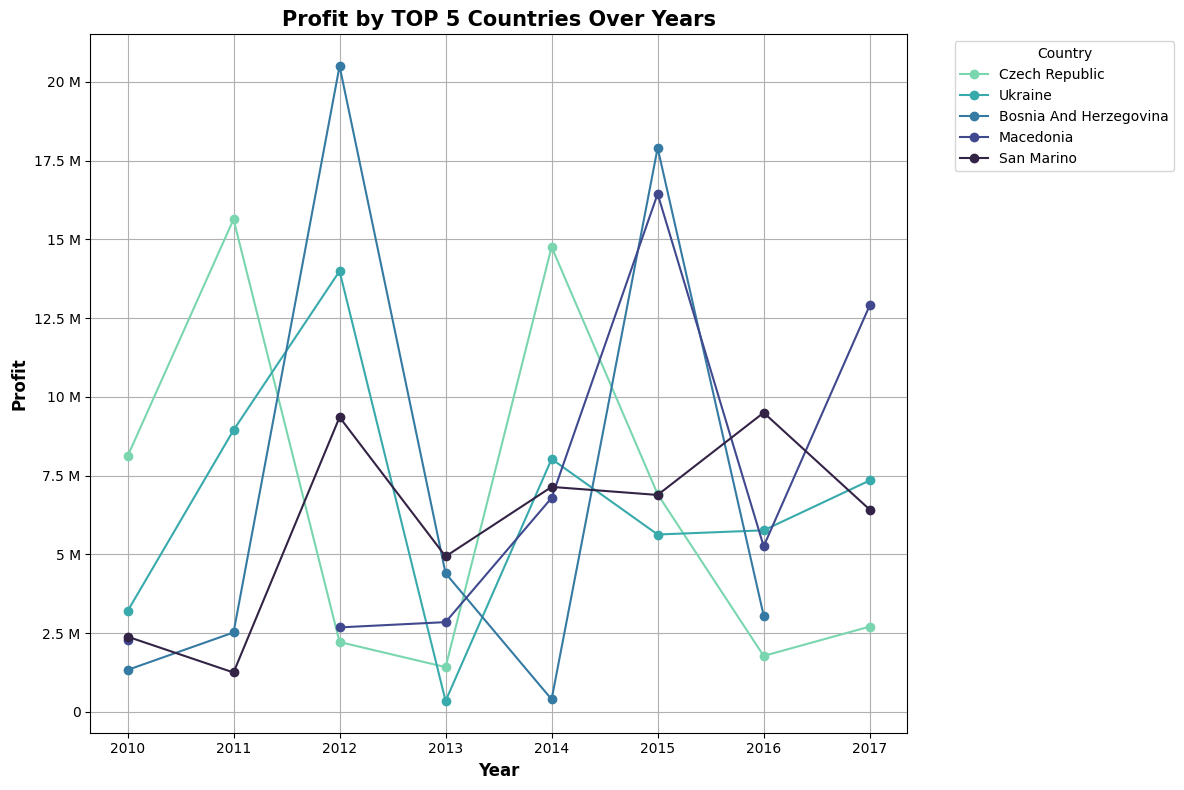

In [ ]:
# Попереднє групування по країнам для фільтрації
total_profit_per_country = df.groupby('country')['profit'].sum().sort_values(ascending=False).head(5)
# ТОП 5 країн
top_5_country_names = total_profit_per_country.index.tolist()
# Групування по рокам і країнам
gr_country_profit_time = df.groupby(['year', 'country'])['profit'].sum().unstack('country')
# Фільтрація, Топ 5 країн за прибутком по роках
gr_country_profit_time_top5 = gr_country_profit_time[top_5_country_names]
# Розмір
plt.figure(figsize=(12,8))
# Створення лінійного графіка
gr_country_profit_time_top5.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette(
        'mako_r'
        , n_colors=len(gr_country_profit_time_top5.columns)
        )
)

plt.title(
    'Profit by TOP 5 Countries Over Years'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Year'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Profit'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Country'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left'
    )
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

**ТОП 5 країн:**
1. Czech Republic
2. Ukraine
3. Bosnia And Herzegovina
4. Macedonia
5. San Marino

- 2010–2012: Гарний ріст у більшості країн
- 2012–2013: Різке падіння (перша криза),по всіх країнах.
Різкі коливання прибутку у 2012–2013 роках чітко корелюють із макроекономічною кризою в Єврозоні- 2013–2015: Поступове відновлення — прибуток рухався до колишніх максимумів,але не зміг їх оновити.
- 2015–2016: Стрімке та глибоке падіння продажів.
- 2016–2017: Невелике покращення (корекція), але загального зростання та відновлення ринку так і не відбулося.

Висновок: Після 2015 року ринок у цих країнах увійшов у затяжну кризу і на колишній високий рівень прибутку так і не вийшов.

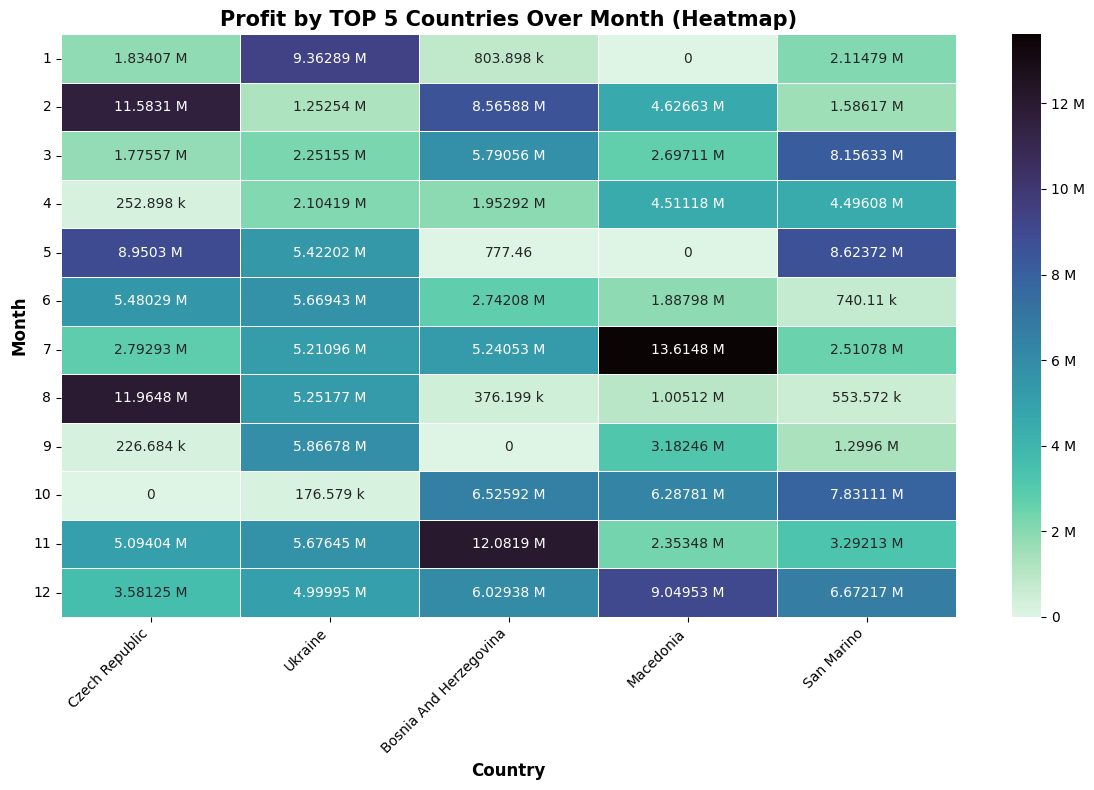

In [ ]:

# Попереднє групування для фільтрації, та виділення 5 країн
total_profit_per_country = df.groupby('country')['profit'].sum().sort_values(ascending=False).head(5)
# Перетворення в список
top_5_country_names = total_profit_per_country.index.tolist()
# Групування за місяцем та країною
gr_country_profit_time = df.groupby(['month', 'country'])['profit'].sum().unstack('country').fillna(0)
# Фільтрування,щоб було лише 5 граїн
gr_country_profit_time_top5 = gr_country_profit_time[top_5_country_names]

# Створення форматера для анотацій
formatter = ticker.EngFormatter()
formatted_annotations = gr_country_profit_time_top5.stack().map(lambda x: formatter(x) if pd.notna(x) else '0').unstack()

# Розмір
plt.figure(figsize=(12,8))
# Створення теплової карти
sns.heatmap(
    gr_country_profit_time_top5,
    annot=formatted_annotations,
    fmt='',
    linewidths=.5,
    cmap='mako_r',
    ax=plt.gca(),
    cbar_kws={'format': formatter}

)

plt.title(
    'Profit by TOP 5 Countries Over Month (Heatmap)'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Country'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Month'
    , fontsize=12
    , fontweight='bold'
    )
plt.yticks(
    ticks=np.arange(0.5, len(gr_country_profit_time_top5.index))
    , labels=gr_country_profit_time_top5.index.map(str)
    , rotation=0
    )
plt.xticks(
    rotation=45
    , ha='right'
    )
plt.tight_layout()
plt.show()

###**Czech Republic**
**Найкращий місяць :**  8  та 2

**Найгірший місяць :**  4 та 9

Також у 10місяці не було продажів зовсім

###**Ukraine**
Найкращий місяць :  1

Найгірший місяць  :  10


###**Bosnia And Herzegovina**
Найкращий місяць  :  11

Найгірший місяць :  5

Також у 9 місяці не було продажів зовсім


###**Macedonia**
Найкращий місяць  :  7

Найгірший місяць :  8

Також у 1 та 5 місяці не було продажів зовсім


###**San Marino**
Найкращий місяць  :   3 та 5

Найгірший місяць:  6 та 8

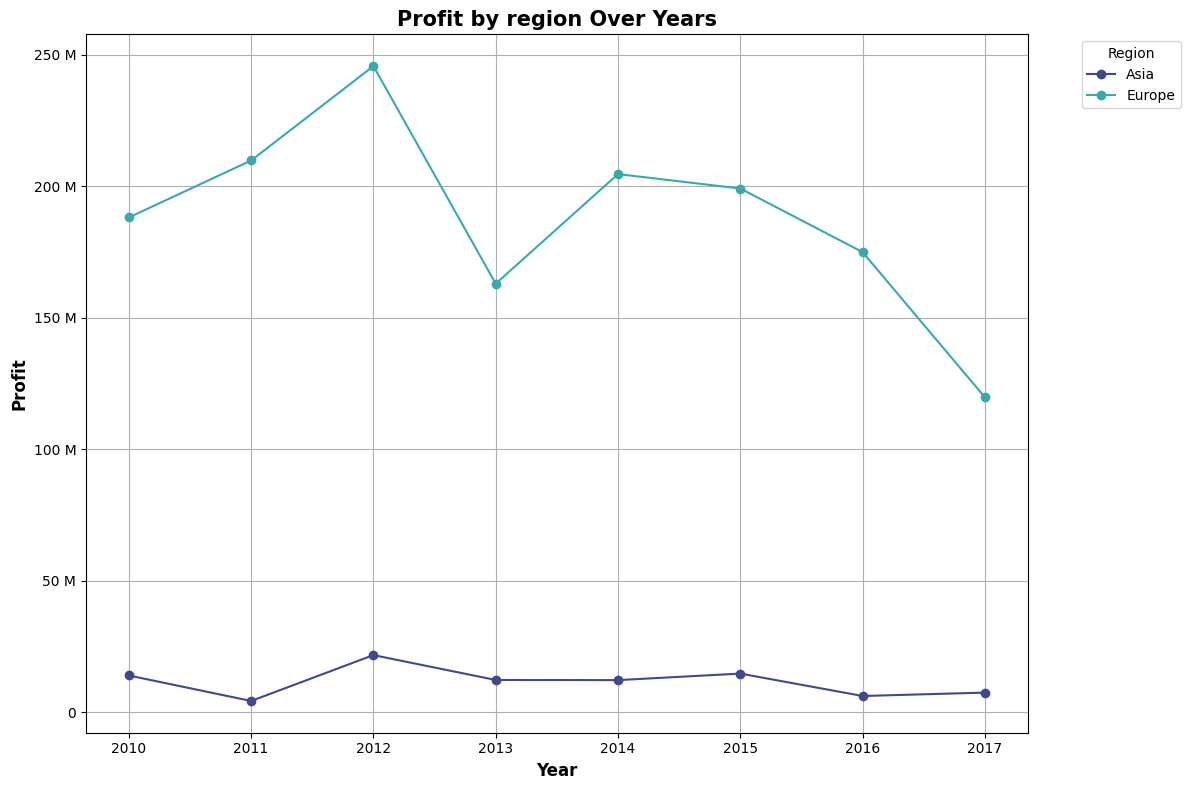

In [ ]:
# Попереднє групування
gr_region_profit_time = df.groupby(['year', 'region'])['profit'].sum().unstack('region')
# Розмір
plt.figure(figsize=(12,8))
# Створення лінійного графіку
gr_region_profit_time.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette(
        'mako'
        , n_colors=len(gr_region_profit_time.columns)
        )
)

plt.title(
    'Profit by region Over Years'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Year'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Profit'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Region'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left')
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

На лінійному графіку видно,що у Европі з 2010 по 2012 була позитивна динаміка прибутку, з 2012 по 2013 стрімке падіння, з 2013 по 2014 була спроба відновитися, та з 2014 почалась негативна динаміка

По Азії видно, що графік лінійно-горизонтальна,та не має сильних коливань

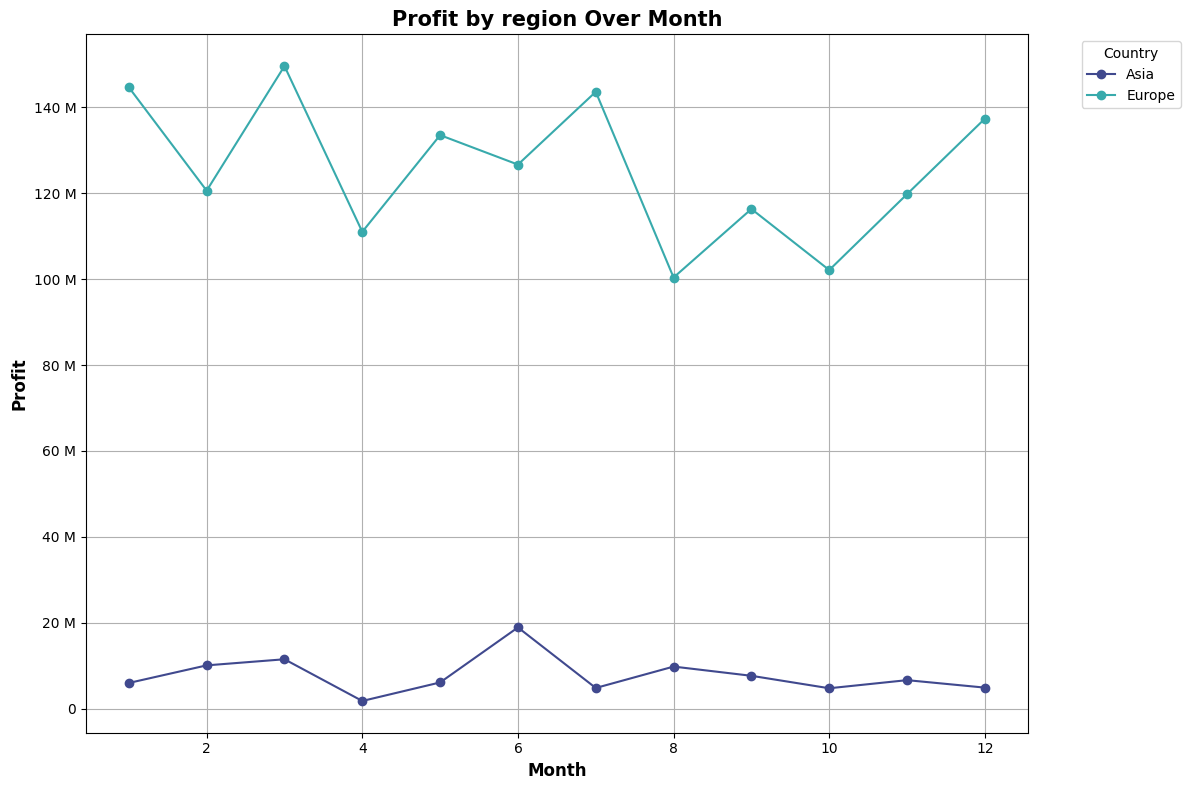

In [ ]:
# Попереднє групування
gr_region_profit_month = df.groupby(['month', 'region'])['profit'].sum().unstack('region')
# Розмір
plt.figure(figsize=(12,8))
# Створення лінійного графіку
gr_region_profit_month.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette(
        'mako'
        , n_colors=len(gr_region_profit_month.columns)
        )
)

plt.title(
    'Profit by region Over Month'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Month'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Profit'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Country'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left'
    )
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

На лінійному графіку,можна побачити,чітку закономірність по Європі,що майже кожен місяць графік розвертається. Тобто,якщо у цьому місяці був спад,то у наступному буде приріст профіту. Прибуток дуже високий, але нестабільний — постійно скаче в межах 100–150 млн. Найкращі місяці : січень (1), березень (3) та липень (7), а найсильніший спад зафіксовано в серпні (8) та в жовтні(10).

По Азії стабільно низькі показники: Прибуток тримається на мінімальному рівні майже кожен місяць лінія лежить біля позначки 5–10 млн. Невеликий сплеск активності помітно лише у червні (6), де прибуток піднявся майже до 20 млн.

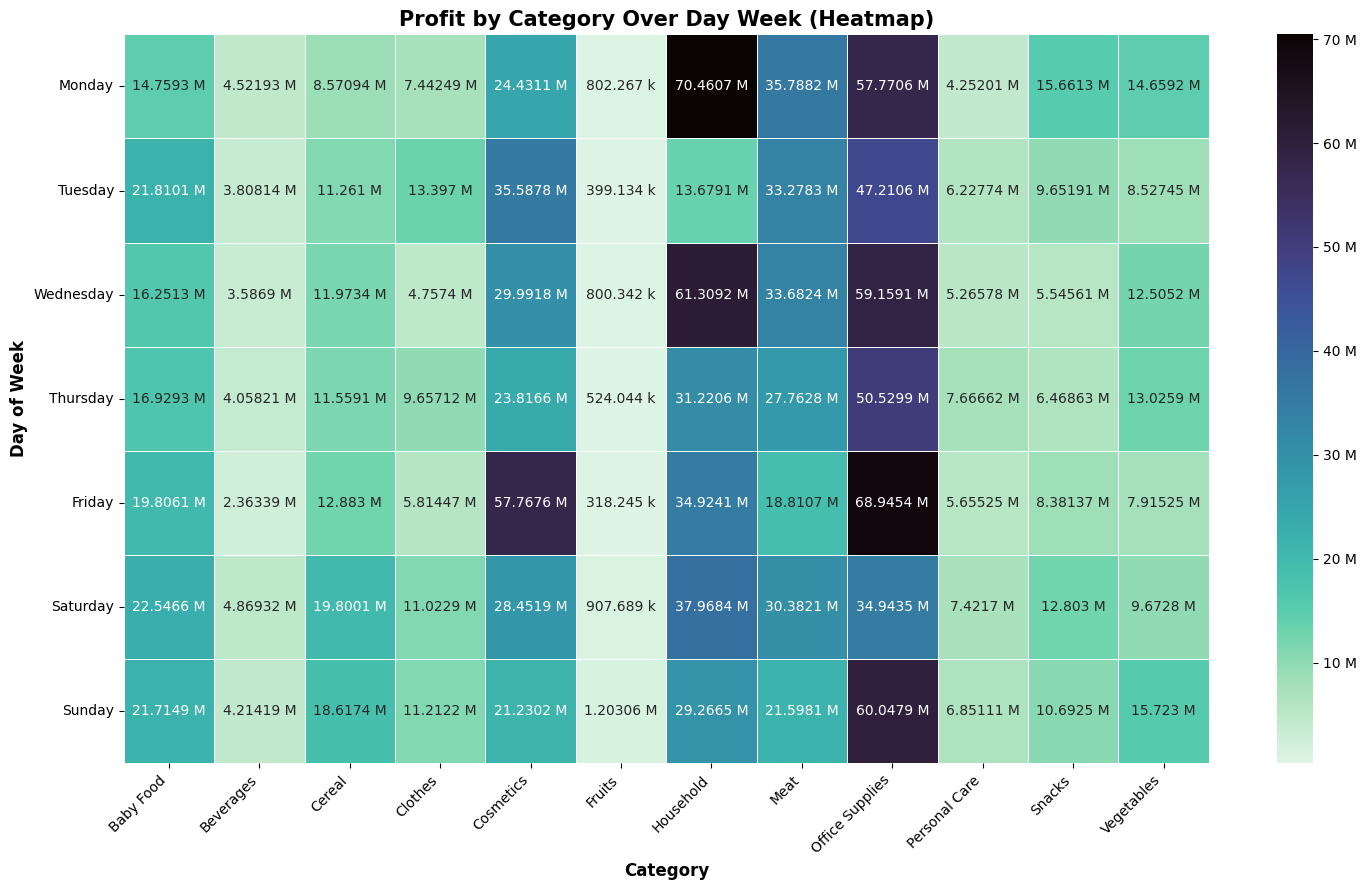

In [ ]:
# Створення стовпця з днями тижня
df['day_week'] = df['order_date'].dt.day_name()
# Список днів тижня по порядку
day_week_index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Перетворення текстового стовпця з днями тижня у спеціальний категоріальний тип даних із заданим правильним порядком.
df['day_week']= pd.Categorical(df['day_week'], categories= day_week_index )

# Групування категорій за днями тижня і профітом
gr_categoty_profit_day_week = df.groupby(['item_type', 'day_week'], observed=False)['profit'].sum().unstack(level=0).fillna(0)

# Формат
formatter = ticker.EngFormatter()
# Форматування для аннотацій
formatted_annotations = gr_categoty_profit_day_week.stack().map(lambda x: formatter(x) if pd.notna(x) else '0').unstack()

# Розмір
plt.figure(figsize=(15,9))
# Створення теплової карти
sns.heatmap(
    gr_categoty_profit_day_week,
    annot=formatted_annotations,
    fmt='',
    cmap='mako_r',
    linewidths=.5,
    ax=plt.gca(),
    cbar_kws={'format': formatter}
)

plt.title(
    'Profit by Category Over Day Week (Heatmap)'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Category'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Day of Week'
    , fontsize=12
    , fontweight='bold'
    )
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


 **1. Лідер по профіту:** Office Supplies (піки: Пн, Ср, Пт, Нд).

 **2. Дводенний пік :**  Cereal(Сб, Нд), Vegetables ( Пн/Нд), Household (Пн, Ср).

**3. Триденний пік:** Clothes (Вт, Сб, Нд), Snacks (Пн, Сб, Нд), та Baby Food(Вт, Сб, Нд)

 **4. П'ятничний тренд:** Cosmetics (пік у Пт).

 **5. Стабільні категорії:** Fruits(невеликий пік у Нд), Beverages, Meat , Personal Care (низький рівний дохід).


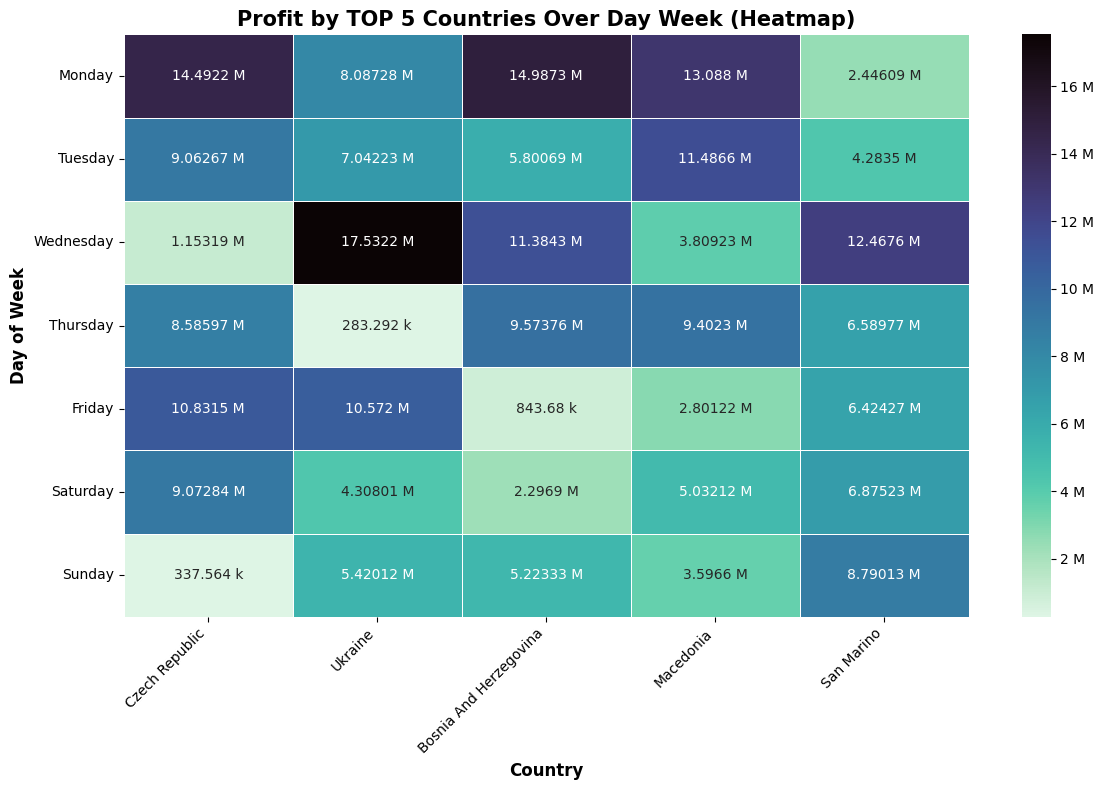

In [ ]:
# Попереднє групування країн по профіту
total_profit_per_country = df.groupby('country')['profit'].sum().sort_values(ascending=False).head(5)
# Перетворення у список
top_5_country_names = total_profit_per_country.index.tolist()
# Список днів тижня по порядку
day_week_index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Перетворення текстового стовпця з днями тижня у спеціальний категоріальний тип даних із заданим правильним порядком.
df['day_week']= pd.Categorical(df['day_week'], categories= day_week_index )
# Групування за днем тижня і країною по профіту
gr_country_profit_day_week = df.groupby(['day_week', 'country'], observed=False)['profit'].sum().unstack('country').fillna(0)
# Фільтрація, топ 5 країн
gr_country_profit_day_week_top5 = gr_country_profit_day_week[top_5_country_names]

# Створення форматера для анотацій
formatter = ticker.EngFormatter()
# Форматування для аннотацій
formatted_annotations = gr_country_profit_day_week_top5.stack().map(lambda x: formatter(x) if pd.notna(x) else '0').unstack()

# Розмір
fig, ax = plt.subplots(figsize=(12,8))
# Створення теплової карти
sns.heatmap(
    gr_country_profit_day_week_top5
    ,annot=formatted_annotations
    ,fmt=''
    ,cmap='mako_r'
    ,linewidths=.5
    ,ax=ax
    ,cbar_kws={'format': formatter}
)

plt.title(
    'Profit by TOP 5 Countries Over Day Week (Heatmap)'
    , fontsize=15
    , fontweight='bold'
    )
plt.xlabel(
    'Country'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Day of Week'
    , fontsize=12
    , fontweight='bold'
    )
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Ключові висновки аналізу :
- В Україні та Сан Маріно покупки найбільше робляться у Cр
- В Чешскій Республіці , Боснії та Герцеговині та Македонії  основним днем для покупок є Пн


##**Аналітичний звіт щодо продажів та операційної ефективності (2010–2017 рр.)**
###**1. Ключові показники (KPI) за звітний період**

**Аналізований період:** 01.01.2010 – 22.07.2017 (7.5 років)

**Загальний виторг:** $1,598,983,761.26

**Кількість замовлень:** 1,246

**Обсяг продажів :** 6,171,671 одиниць товару

**Географічне охоплення:** 45 країн (основний ринок — Європа)

###**2. Географічний аналіз: Ефективність ринків**

**TOП 3 за маржинальністю:** Чехія, Україна, Боснія і Герцеговина. Ці ринки є найбільш рентабельними для компанії.

**TOП 3  за кількістю проданих одиниць:** Македонія, Сан-Марино, Андорра. Вони забезпечують високий оборот товару, але мають нижчу маржинальність.

####**Інсайт:**

Аналіз виявив чітку розбіжність між країнами-лідерами за обсягом продажів та країнами, які генерують реальний дохід.

####**Висновки:**

Така розбіжність вказує на відмінності у споживчому кошику. Ринки Македонії, Сан-Марино та Андорри генерують високий трафік за рахунок дешевих низькомаржинальних категорій , тоді як Чехія, Україна та Боснія забезпечують високий середній чек та маржинальність за рахунок преміальних категорій.

Це чудова точка для росту бізнесу: у Македонії та Сан-Марино вже є лояльна база, яка купує багато речей, — тепер їм потрібно почати активно пропонувати (робити апсейл) дорожчі товари, щоб підняти там прибутковість.

###**3. Продуктовий аналіз та матриця прибутковості (Аналіз Парето)**

**Продуктовий портфель демонструє класичний дисбаланс Парето:** обсяги продажів розподілені між категоріями рівномірно, проте основний прибуток генерують лише 5 категорій (Група А).

**Абсолютний лідер:** Категорія «Office Supplies» є бестселером, посідаючи 1-ше місце одночасно за популярністю, виторгом та чистим прибутком.

**Високомаржинальна категорія:**  «Household» посідає 2-ге місце за прибутком, попри найнижчий обсяг продажів у штуках. Це свідчить про високу преміальність та маржинальність товару.

**Генератори трафіку :** Категорії «Personal Care», «Beverages» та «Fruit» мають високі показники продажів у штуках, але низьку прибутковість.

###**4. Канали продажів та Логістика**
**Канали дистрибуції:** Порівняльний аналіз онлайн та офлайн каналів (або інших джерел трафіку) показав абсолютну стабільність — вони працюють однаково ефективно, генеруючи майже рівні частки прибутку.

**Логістична ефективність серед категорій:** Середній інтервал доставки між категоріями коливається в межах 20–27 днів.

**Логістична ефективність серед країн:** Середній інтервал доставки між країнами коливається в межах 18–33 днів.

####**Інсайт:**
 Статистично значущої кореляції між тривалістю доставки та рівнем прибутку не виявлено. Збільшення терміну доставки в межах цього діапазону не веде до втрати клієнтів чи зниження доходу.


###**5. Сезонність та Поведінкові патерни клієнтів**

Є сезонність по країнах за роками,але вона пов'язана з макроєкономічними факторами.
За місяцями також спостерігається невелика сезонність,але вона індивідуальна для кожної країни і немає загальної закономірності.

**Проте зафіксовано локальні мікротренди за днями тижня у топ 5 карїн за прибутком:**
«Середа» як купівельний пік: Характерна для споживачів в Україні та Сан-Марино.
«Понеділок» як купівельний пік: Найвища активність на початку тижня спостерігається в Чехії, Македонії, Боснії та Герцеговині.

####**Глибокий аналіз категорій за днями тижня**
**Абсолютний лідер («Office Supplies»):** Демонструє стабільно високий профіт протягом усього тижня, але має чіткі пульсуючі піки в понеділок, середу, п’ятницю та неділю.

**Дводенні піки:**

Cereal: Купують переважно на вихідних (субота, неділя).

Vegetables: Сплеск активності припадає на стик тижнів (неділя, понеділок).

Household: Фокусується на початку та середині робочого тижня (понеділок, середа).

**Триденний пік:**
Категорії Clothes, Snacks та Baby Food мають ідентичний патерн — продажі активізуються у вівторок, а потім виходять на максимум у вихідні (субота, неділя).

**П’ятничний тренд» (Cosmetics):** Категорія косметики має один яскраво виражений пік у п'ятницю (ідеальний час для маркетингових акцій перед вихідними).

**Стабільний попит :** Категорії Fruits (з мінімальним підйомом у неділю), Beverages, Meat та Personal Care демонструють рівний, прогнозований, хоч і невисокий дохід без коливань протягом тижня.

###**6. Стратегічні рекомендації**
- Оптимізація маркетингу під локальну сезонність: Налаштувати запуск рекламних кампаній та push-сповіщень відповідно до купівельних піків: у неділю ввечері/понеділок зранку для Чехії та Боснії, та у вівторок/середу — для України.

- Розвиток високомаржинальних категорій: Розширити асортимент у категорії «Household» та збільшити на неї маркетинговий бюджет, оскільки кожен продаж тут приносить максимальний прибуток.
- Крос-продажі : Використовувати категорії-драйвери трафіку («Personal Care», «Beverages», «Fruit») для стимулювання продажів високоприбуткових товарів (наприклад, пропонувати знижки на Office Supplies чи Household при купівлі товарів-лідерів за обсягом).
- Утримання позицій лідера: Підтримувати постійний сток для «Office Supplies», оскільки це головний фундамент стабільності компанії.
